In [1]:
"""
logistics regression

binary classification. sigmoid function. mean log loss is used rather than mean squared error
"""

'\nlogistics regression\n\nbinary classification. sigmoid function. mean log loss is used rather than mean squared error\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 10000

# generate random numbers for 2 classes, avoid overlapping
glucose_neg = np.random.normal(loc=90,  scale=12, size=n//2)
glucose_pos = np.random.normal(loc=160, scale=12, size=n//2)

glucose = np.concatenate([glucose_neg, glucose_pos])
labels  = np.concatenate([np.zeros(n//2), np.ones(n//2)])

# shuffle
idx = np.random.permutation(n)
glucose, labels = glucose[idx], labels[idx]

df = pd.DataFrame({"glucose_level": glucose.round(1), "diabetic": labels.astype(int)})

# train / test split
X = df[["glucose_level"]].values
y = df["diabetic"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (8000, 1) | Test: (2000, 1)


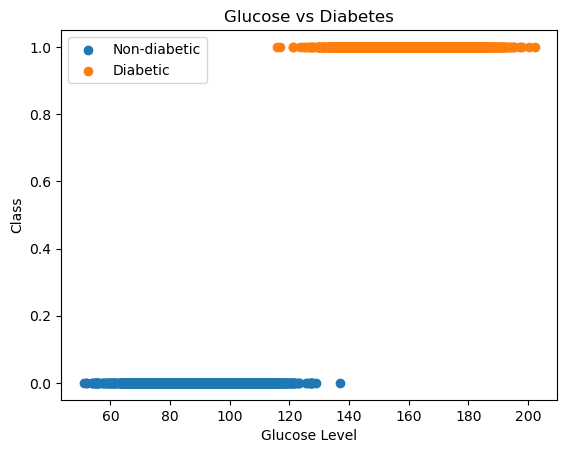

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X_train[y_train==0], y_train[y_train==0], label="Non-diabetic")
plt.scatter(X_train[y_train==1], y_train[y_train==1], label="Diabetic")

plt.xlabel("Glucose Level")
plt.ylabel("Class")
plt.title("Glucose vs Diabetes")
plt.legend()

plt.show()

In [4]:
"""
X
↓
z = Xw + b
↓
y_pred = sigmoid(z)
↓
log loss(y_true, y_pred)

sigmoid function : 1 / (1 + e^(-z))
log loss function : - 1/n * sum((yTrue * log(yPred)) + ((1 - yTrue) * log(1 - yPred)))
upon deriving the log loss fn wrt weight and bias, we get the gradients as below : 

dw = (1 / n_samples) * (X.T @ (y_pred - y))
db = (1 / n_samples) * np.sum(y_pred - y)
"""

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_probability(X, weights, bias):
    z = X @ weights + bias     
    y_pred = sigmoid(z)        
    return y_pred

def log_loss(y_true, y_pred):
    # avoid log(0) via clipping the y_pred
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    
    N = len(y_true)    
    loss = - (1 / N) * np.sum( y_true * np.log( y_pred ) +(1 - y_true) * np.log(1 - y_pred))    
    return loss

def gradient_descent(X, y, lr, epochs):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    for i in range(epochs):

        # forward pass
        y_pred = predict_probability(X, weights, bias)

        # gradients
        dw = (1 / n_samples) * (X.T @ (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)

        # update parameters
        weights = weights - lr * dw
        bias = bias - lr * db

        # monitor loss
        if i % 100 == 0:
            loss = log_loss(y, y_pred)
            print(f"epoch {i}  loss {loss:.4f}")

    return weights, bias

In [5]:
# normalise the training dataset
X_train = (X_train - X_train.mean()) / X_train.std()
weights, bias = gradient_descent(X_train, y_train, 0.01, 1000)

print("\nweights:", weights)
print("bias:", bias)

epoch 0  loss 0.6931
epoch 100  loss 0.5165
epoch 200  loss 0.4062
epoch 300  loss 0.3336
epoch 400  loss 0.2831
epoch 500  loss 0.2463
epoch 600  loss 0.2183
epoch 700  loss 0.1964
epoch 800  loss 0.1789
epoch 900  loss 0.1645

weights: [2.113881]
bias: -0.006455094106680709


In [6]:
# evaluate
X_test = (X_test - X_test.mean()) / X_test.std()

y_prob = predict_probability(X_test, weights, bias)
y_pred = (y_prob >= 0.5).astype(int)
accuracy = np.mean(y_pred == y_test)
test_loss = log_loss(y_test, y_prob)

print("Accuracy:", accuracy)
print("Test log loss:", test_loss)

Accuracy: 0.997
Test log loss: 0.1551099895598141


In [7]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 986    2]
 [   4 1008]]


In [8]:
# the model was failing to learn before normalizing the predictors

In [9]:
"""
since the dataset is prepared explicitly without using the weights, there could be numerous values for these weights
also it will be a wrong expectation to match the weights with other different classification algorithms
because their methods of classifying are different

| Algorithm           | What it learns               |
| ------------------- | ---------------------------- |
| Logistic Regression | probability boundary         |
| LDA                 | Gaussian class distributions |
| Naive Bayes         | conditional probabilities    |
| KNN                 | neighbor voting              |
| Decision Tree       | rule splits                  |
| SVM                 | maximum margin boundary      |

but what we can compare instead are the accuracy and confusion matrix
"""

'\nsince the dataset is prepared explicitly without using the weights, there could be numerous values for these weights\nalso it will be a wrong expectation to match the weights with other different classification algorithms\nbecause their methods of classifying are different\n\n| Algorithm           | What it learns               |\n| ------------------- | ---------------------------- |\n| Logistic Regression | probability boundary         |\n| LDA                 | Gaussian class distributions |\n| Naive Bayes         | conditional probabilities    |\n| KNN                 | neighbor voting              |\n| Decision Tree       | rule splits                  |\n| SVM                 | maximum margin boundary      |\n\nbut what we can compare instead are the accuracy and confusion matrix\n'

In [10]:
# run the sklearn logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.997
Log loss: 0.012345176755132727
Confusion matrix:
 [[ 986    2]
 [   4 1008]]


In [11]:
# quickly visualise the histogram of glucose_level and see whether its a normal distribution to apply LDA

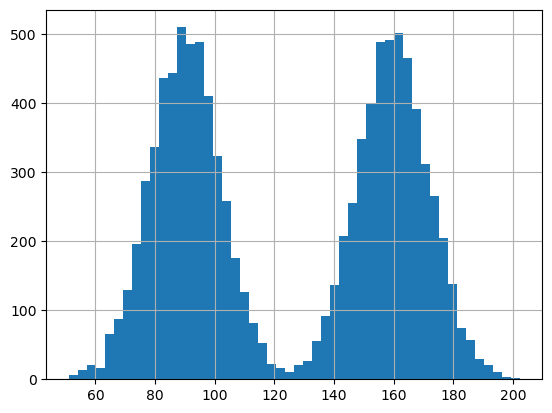

In [12]:
df['glucose_level'].hist(bins=50);

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df[["glucose_level"]].values
y = df["diabetic"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(X_train, y_train)
y_pred = lda_classifier.predict(X_test)

In [14]:
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.997
Log loss: 17.805564774223868
Confusion matrix:
 [[ 986    2]
 [   4 1008]]


In [15]:
lda_classifier.coef_, lda_classifier.intercept_

(array([[0.48803042]]), array([-61.02802242]))

In [16]:
# LDA had same accuracy as logistic regression.
# log loss is more. thats expected since LDA doesnt optimise to minimise the log loss.
# Instead, it assumes Gaussian class-conditional distributions with a shared covariance matrix and derives the decision boundary using Bayes rule.